# **The XOR Problem: Understanding Non-Linear Learning with Neural Networks**


---

## **Learning Objectives**

By the end of this tutorial, students will be able to:

1. **Understand** why linear models fail to solve the XOR problem
2. **Implement** a 2-2-1 neural network architecture by hand calculations
3. **Calculate** forward propagation, loss computation, and backpropagation manually
4. **Visualize** how hidden layers create non-linear decision boundaries
5. **Analyze** gradient flow and weight updates in multi-layer networks
6. **Compare** linear vs. non-linear model performance on XOR data

---

## **Prerequisites**

- Understanding of basic linear algebra (matrix multiplication, dot products)
- Knowledge of activation functions (sigmoid, tanh, ReLU)
- Familiarity with gradient descent and chain rule
- Basic understanding of neural network concepts

## **1. Overview and Theoretical Framework**

### **1.1 The XOR Problem: A Classic Challenge in Machine Learning**

The **XOR (Exclusive OR) problem** is a fundamental challenge that exposed the limitations of early neural networks (perceptrons) and sparked the development of multi-layer architectures.

**Historical Context:**
- In 1969, Minsky and Papert proved that single-layer perceptrons cannot solve XOR
- This led to the "AI Winter" until multi-layer networks were developed
- XOR became the "Hello World" of neural networks

**Why XOR is Important:**
1. **Non-linearly separable**: Cannot be solved with a single straight line
2. **Minimal complexity**: Only 4 data points, perfect for hand calculations
3. **Fundamental insight**: Demonstrates the power of hidden layers

### **1.2 Mathematical Definition of XOR**

The XOR function returns 1 when inputs are different, 0 when they are the same:

| Input A | Input B | XOR Output |
|---------|---------|------------|
|    0    |    0    |     0      |
|    0    |    1    |     1      |
|    1    |    0    |     1      |
|    1    |    1    |     0      |

**Mathematical Representation:**
- XOR(A, B) = (A ∧ ¬B) ∨ (¬A ∧ B)
- XOR(A, B) = A + B - 2AB (in arithmetic form)

In [ ]:
# Essential imports for numerical computation and visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib for better visualization
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib backend: {plt.get_backend()}")

✅ Libraries imported successfully!
NumPy version: 2.0.2
Matplotlib backend: module://matplotlib_inline.backend_inline


## **2. Why Linear Models Fail: The Separability Problem**

### **2.1 Understanding Linear Separability**

A dataset is **linearly separable** if we can draw a straight line (in 2D) or hyperplane (in higher dimensions) that perfectly separates the classes. Let's visualize why XOR is not linearly separable.

XOR Dataset:
Inputs (X):
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Outputs (y):
[0 1 1 0]

Dataset shape: (4, 2)
Number of samples: 4
Number of features: 2


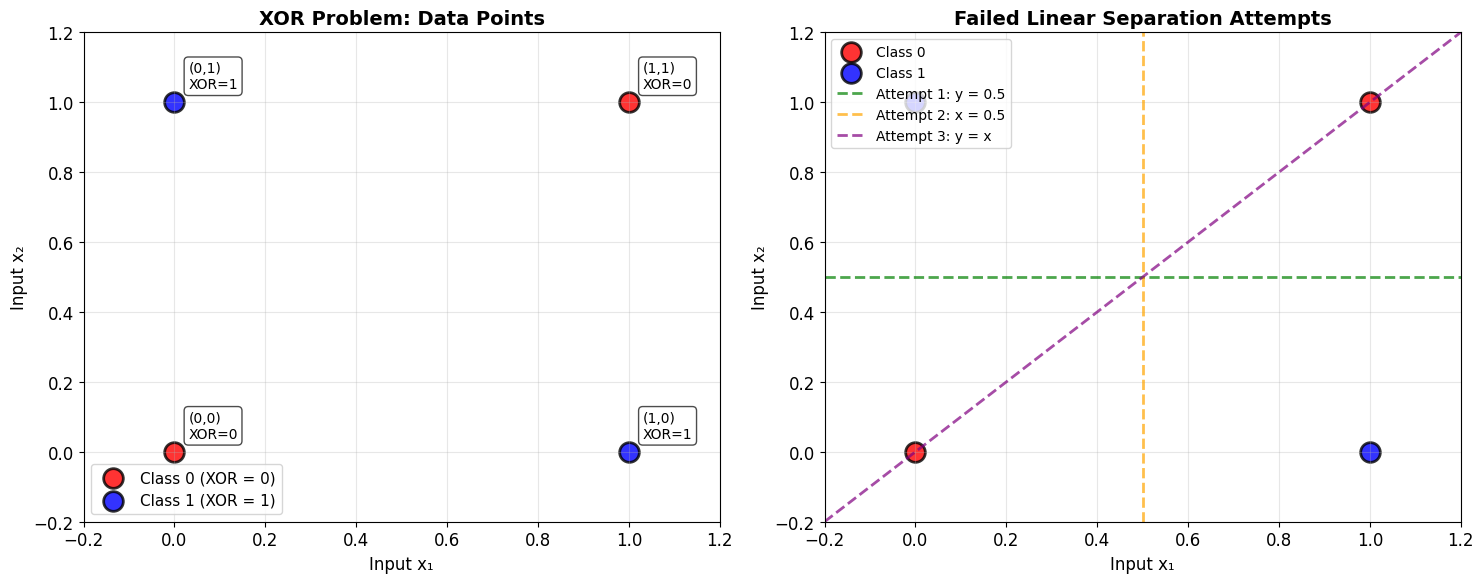


🚫 OBSERVATION: No single straight line can separate the red and blue points!
   This is why we need NON-LINEAR decision boundaries.


In [ ]:
# Create the XOR dataset
# Input features: X = [[x1, x2], ...]
# Target outputs: y = [0, 1, 1, 0]

X = np.array([[0, 0],    # Point 1: (0,0) → 0
              [0, 1],    # Point 2: (0,1) → 1
              [1, 0],    # Point 3: (1,0) → 1
              [1, 1]])   # Point 4: (1,1) → 0

y = np.array([0, 1, 1, 0])  # XOR truth table outputs

print("XOR Dataset:")
print("Inputs (X):")
print(X)
print("\nOutputs (y):")
print(y)
print(f"\nDataset shape: {X.shape}")
print(f"Number of samples: {len(X)}")
print(f"Number of features: {X.shape[1]}")

# Create a beautiful visualization of the XOR problem
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: XOR data points with different colors for each class
colors = ['red', 'blue']
labels = ['Class 0 (XOR = 0)', 'Class 1 (XOR = 1)']

for i, class_label in enumerate([0, 1]):
    mask = y == class_label
    ax1.scatter(X[mask, 0], X[mask, 1],
               c=colors[i], s=200, alpha=0.8,
               label=labels[i], edgecolor='black', linewidth=2)

# Add point labels
for i, (x_coord, y_coord) in enumerate(X):
    ax1.annotate(f'({x_coord},{y_coord})\nXOR={y[i]}',
                (x_coord, y_coord),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax1.set_xlabel('Input x₁', fontsize=12)
ax1.set_ylabel('Input x₂', fontsize=12)
ax1.set_title('XOR Problem: Data Points', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)
ax1.set_xlim(-0.2, 1.2)
ax1.set_ylim(-0.2, 1.2)

# Plot 2: Attempt to draw linear separation lines
ax2.scatter(X[y==0, 0], X[y==0, 1], c='red', s=200, alpha=0.8, label='Class 0', edgecolor='black', linewidth=2)
ax2.scatter(X[y==1, 0], X[y==1, 1], c='blue', s=200, alpha=0.8, label='Class 1', edgecolor='black', linewidth=2)

# Try different linear separators (all will fail)
x_line = np.linspace(-0.2, 1.2, 100)

# Attempt 1: Horizontal line
y_line1 = np.full_like(x_line, 0.5)
ax2.plot(x_line, y_line1, '--', color='green', linewidth=2, alpha=0.7, label='Attempt 1: y = 0.5')

# Attempt 2: Vertical line
ax2.axvline(x=0.5, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Attempt 2: x = 0.5')

# Attempt 3: Diagonal line
y_line3 = x_line
ax2.plot(x_line, y_line3, '--', color='purple', linewidth=2, alpha=0.7, label='Attempt 3: y = x')

ax2.set_xlabel('Input x₁', fontsize=12)
ax2.set_ylabel('Input x₂', fontsize=12)
ax2.set_title('Failed Linear Separation Attempts', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_xlim(-0.2, 1.2)
ax2.set_ylim(-0.2, 1.2)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("🚫 OBSERVATION: No single straight line can separate the red and blue points!")
print("   This is why we need NON-LINEAR decision boundaries.")
print("="*60)

### **2.2 Mathematical Proof: Why Linear Models Cannot Solve XOR**

Let's prove mathematically that no linear function can solve XOR.

**Linear Model:** f(x₁, x₂) = w₁x₁ + w₂x₂ + b

For XOR to be solvable by this linear model, we need:
- f(0,0) = b ≈ 0 (should output 0)
- f(0,1) = w₂ + b ≈ 1 (should output 1)  
- f(1,0) = w₁ + b ≈ 1 (should output 1)
- f(1,1) = w₁ + w₂ + b ≈ 0 (should output 0)

From equations 1 and 2: w₂ ≈ 1  
From equations 1 and 3: w₁ ≈ 1  
From equation 4: w₁ + w₂ + b ≈ 0, so 1 + 1 + 0 = 2 ≈ 0

**Contradiction!** We cannot have 2 ≈ 0, proving that no linear model can solve XOR.

Training Linear Model on XOR...
Epoch	Loss		w1	w2	b	Predictions
----------------------------------------------------------------------
0	0.6988		0.069	0.069	0.050	[0.525 0.55  0.55  0.574]
200	0.6931		0.000	0.000	-0.000	[0.5 0.5 0.5 0.5]
400	0.6931		0.000	0.000	-0.000	[0.5 0.5 0.5 0.5]
600	0.6931		0.000	0.000	-0.000	[0.5 0.5 0.5 0.5]
800	0.6931		0.000	0.000	-0.000	[0.5 0.5 0.5 0.5]

FINAL RESULTS:
Final weights: w1=0.000, w2=0.000, b=-0.000
Final loss: 0.6931

Predictions vs Actual:
Input: [0 0] → Predicted: 0.500, Actual: 0
Input: [0 1] → Predicted: 0.500, Actual: 1
Input: [1 0] → Predicted: 0.500, Actual: 1
Input: [1 1] → Predicted: 0.500, Actual: 0

Accuracy: 50.0%


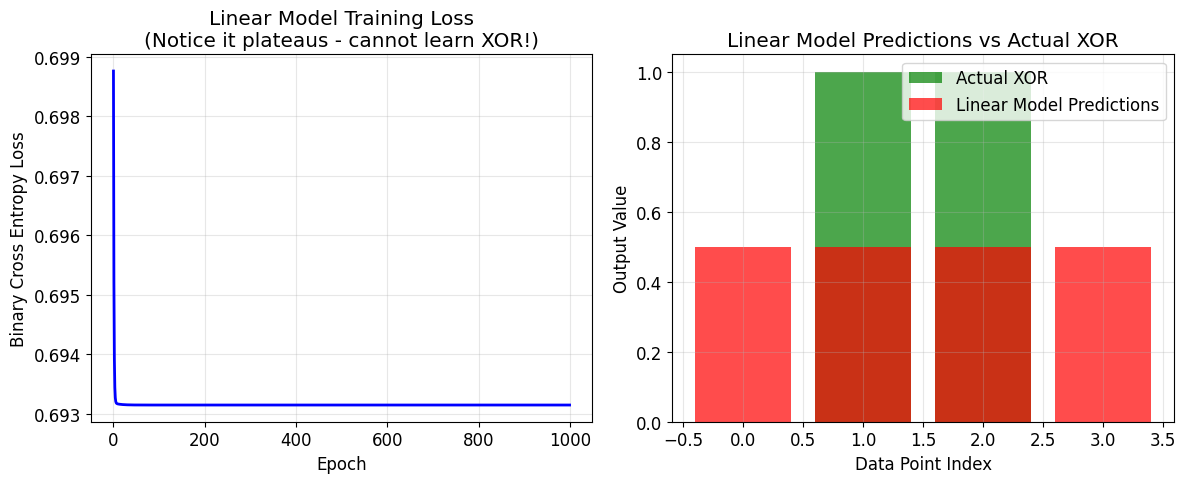


🚫 The linear model CANNOT learn XOR! Maximum accuracy ≈ 50% (random guessing)
🧠 This is why we need HIDDEN LAYERS to create non-linear transformations!


In [ ]:
# Let's actually try to train a linear model and watch it fail!

def linear_model(X, w1, w2, b):
    """
    Linear model: f(x1, x2) = w1*x1 + w2*x2 + b
    """
    return X[:, 0] * w1 + X[:, 1] * w2 + b

def sigmoid(z):
    """Sigmoid activation function"""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))  # Clip to prevent overflow

def binary_cross_entropy(y_true, y_pred):
    """Binary cross entropy loss"""
    epsilon = 1e-15  # Small value to prevent log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Try to train a linear model with gradient descent
w1, w2, b = 0.1, 0.1, 0.1  # Initialize weights
learning_rate = 1.0
epochs = 1000
losses = []

print("Training Linear Model on XOR...")
print("Epoch\tLoss\t\tw1\tw2\tb\tPredictions")
print("-" * 70)

for epoch in range(epochs):
    # Forward pass
    z = linear_model(X, w1, w2, b)
    y_pred = sigmoid(z)
    loss = binary_cross_entropy(y, y_pred)
    losses.append(loss)

    # Backward pass (compute gradients)
    dz = y_pred - y  # Derivative of BCE w.r.t. z
    dw1 = np.mean(dz * X[:, 0])
    dw2 = np.mean(dz * X[:, 1])
    db = np.mean(dz)

    # Update weights
    w1 -= learning_rate * dw1
    w2 -= learning_rate * dw2
    b -= learning_rate * db

    # Print progress every 200 epochs
    if epoch % 200 == 0:
        pred_rounded = np.round(y_pred, 3)
        print(f"{epoch}\t{loss:.4f}\t\t{w1:.3f}\t{w2:.3f}\t{b:.3f}\t{pred_rounded}")

# Final results
print("\n" + "="*70)
print("FINAL RESULTS:")
print(f"Final weights: w1={w1:.3f}, w2={w2:.3f}, b={b:.3f}")
print(f"Final loss: {loss:.4f}")
print("\nPredictions vs Actual:")
for i in range(4):
    print(f"Input: {X[i]} → Predicted: {y_pred[i]:.3f}, Actual: {y[i]}")

# Calculate accuracy
predictions_binary = (y_pred > 0.5).astype(int)
accuracy = np.mean(predictions_binary == y)
print(f"\nAccuracy: {accuracy:.1%}")

# Plot the loss curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Binary Cross Entropy Loss')
plt.title('Linear Model Training Loss\n(Notice it plateaus - cannot learn XOR!)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(range(4), y, alpha=0.7, label='Actual XOR', color='green')
plt.bar(range(4), y_pred, alpha=0.7, label='Linear Model Predictions', color='red')
plt.xlabel('Data Point Index')
plt.ylabel('Output Value')
plt.title('Linear Model Predictions vs Actual XOR')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🚫 The linear model CANNOT learn XOR! Maximum accuracy ≈ 50% (random guessing)")
print("🧠 This is why we need HIDDEN LAYERS to create non-linear transformations!")

## **3. The Neural Network Solution: 2-2-1 Architecture**

### **3.1 Network Architecture Design**

To solve XOR, we need a **multi-layer neural network** that can create non-linear decision boundaries. Our architecture:

**Input Layer:** 2 neurons (x₁, x₂)  
**Hidden Layer:** 2 neurons (h₁, h₂) with sigmoid activation  
**Output Layer:** 1 neuron (ŷ) with sigmoid activation  

```
Input Layer    Hidden Layer    Output Layer
     x₁ ──────→ h₁ ──────────→
               ╱  ╲            ŷ
     x₂ ──────→ h₂ ──────────→
```

### **3.2 Mathematical Formulation**

**Hidden Layer Computations:**
- z₁ = w₁₁x₁ + w₁₂x₂ + b₁
- h₁ = σ(z₁) = 1/(1 + e^(-z₁))
- z₂ = w₂₁x₁ + w₂₂x₂ + b₂  
- h₂ = σ(z₂) = 1/(1 + e^(-z₂))

**Output Layer Computation:**
- z₃ = w₃₁h₁ + w₃₂h₂ + b₃
- ŷ = σ(z₃) = 1/(1 + e^(-z₃))

**Loss Function:**
- L = -[y log(ŷ) + (1-y) log(1-ŷ)]  (Binary Cross Entropy)

### **3.3 Why This Works: Intuitive Explanation**

The hidden layer creates **feature combinations** that make the problem linearly separable:
- h₁ might learn to detect "x₁ OR x₂"
- h₂ might learn to detect "x₁ AND x₂"
- The output layer then combines: XOR ≈ (x₁ OR x₂) AND NOT(x₁ AND x₂)

In [ ]:
class XORNeuralNetwork:
    """
    A 2-2-1 Neural Network for solving the XOR problem
    Perfect for hand calculations and educational purposes
    """

    def __init__(self):
        """Initialize weights and biases with small random values"""
        # Hidden layer weights (2x2 matrix: 2 inputs to 2 hidden neurons)
        self.W1 = np.random.randn(2, 2) * 0.5
        self.b1 = np.random.randn(2) * 0.5

        # Output layer weights (2x1 matrix: 2 hidden to 1 output)
        self.W2 = np.random.randn(2, 1) * 0.5
        self.b2 = np.random.randn(1) * 0.5

        # For storing intermediate values during forward pass
        self.z1 = None  # Hidden layer pre-activation
        self.h1 = None  # Hidden layer post-activation
        self.z2 = None  # Output layer pre-activation
        self.y_pred = None  # Final prediction

    def sigmoid(self, z):
        """Sigmoid activation function with numerical stability"""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def sigmoid_derivative(self, z):
        """Derivative of sigmoid function"""
        s = self.sigmoid(z)
        return s * (1 - s)

    def forward(self, X):
        """
        Forward propagation through the network

        Args:
            X: Input data (4x2 matrix for XOR problem)

        Returns:
            y_pred: Network predictions
        """
        # Hidden layer computation
        self.z1 = np.dot(X, self.W1) + self.b1  # Shape: (4, 2)
        self.h1 = self.sigmoid(self.z1)         # Shape: (4, 2)

        # Output layer computation
        self.z2 = np.dot(self.h1, self.W2) + self.b2  # Shape: (4, 1)
        self.y_pred = self.sigmoid(self.z2).flatten() # Shape: (4,)

        return self.y_pred

    def compute_loss(self, y_true, y_pred):
        """Compute binary cross entropy loss"""
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def backward(self, X, y_true):
        """
        Backward propagation (backpropagation) to compute gradients

        Args:
            X: Input data
            y_true: True labels

        Returns:
            gradients: Dictionary containing all gradients
        """
        m = X.shape[0]  # Number of samples

        # Output layer gradients
        dL_dy = self.y_pred - y_true  # Shape: (4,)
        dL_dz2 = dL_dy  # For sigmoid, dy/dz = y(1-y), but we can simplify
        dL_dz2 = dL_dz2.reshape(-1, 1)  # Shape: (4, 1)

        dL_dW2 = np.dot(self.h1.T, dL_dz2) / m  # Shape: (2, 1)
        dL_db2 = np.mean(dL_dz2, axis=0)        # Shape: (1,)

        # Hidden layer gradients
        dL_dh1 = np.dot(dL_dz2, self.W2.T)  # Shape: (4, 2)
        dL_dz1 = dL_dh1 * self.sigmoid_derivative(self.z1)  # Shape: (4, 2)

        dL_dW1 = np.dot(X.T, dL_dz1) / m  # Shape: (2, 2)
        dL_db1 = np.mean(dL_dz1, axis=0)  # Shape: (2,)

        return {
            'dW2': dL_dW2, 'db2': dL_db2,
            'dW1': dL_dW1, 'db1': dL_db1
        }

    def update_weights(self, gradients, learning_rate):
        """Update weights using gradient descent"""
        self.W2 -= learning_rate * gradients['dW2']
        self.b2 -= learning_rate * gradients['db2']
        self.W1 -= learning_rate * gradients['dW1']
        self.b1 -= learning_rate * gradients['db1']

    def get_weights_summary(self):
        """Get a formatted summary of current weights"""
        return {
            'Hidden Layer Weights (W1)': self.W1,
            'Hidden Layer Biases (b1)': self.b1,
            'Output Layer Weights (W2)': self.W2.flatten(),
            'Output Layer Bias (b2)': self.b2
        }

# Create and initialize the neural network
nn = XORNeuralNetwork()

print("🧠 Neural Network initialized!")
print("="*60)
print("INITIAL WEIGHTS AND BIASES:")
weights_summary = nn.get_weights_summary()
for key, value in weights_summary.items():
    print(f"{key}:")
    print(f"  {value}")
print("="*60)

🧠 Neural Network initialized!
INITIAL WEIGHTS AND BIASES:
Hidden Layer Weights (W1):
  [[ 0.24835708 -0.06913215]
 [ 0.32384427  0.76151493]]
Hidden Layer Biases (b1):
  [-0.11707669 -0.11706848]
Output Layer Weights (W2):
  [0.78960641 0.38371736]
Output Layer Bias (b2):
  [-0.23473719]


## **4. Hand Calculations: Step-by-Step Walkthrough**

### **4.1 Setting Up Specific Weights for Manual Calculation**

For educational purposes, let's use **specific, simple weights** that make hand calculations easier. We'll use these values and walk through ONE complete forward pass and backward pass step by step.

In [ ]:
# Set up specific weights for easy hand calculation
# These are chosen to be simple numbers that are easy to compute by hand

print("🔧 Setting up weights for hand calculation example...")
print("="*70)

# Initialize a new network with specific weights
nn_manual = XORNeuralNetwork()

# Hidden layer weights: W1 (2x2 matrix)
# W1[i,j] = weight from input i to hidden neuron j
nn_manual.W1 = np.array([[1.0, -1.0],   # Input x1 to [h1, h2]
                         [1.0, -1.0]])  # Input x2 to [h1, h2]

# Hidden layer biases
nn_manual.b1 = np.array([0.0, 1.0])     # Bias for [h1, h2]

# Output layer weights: W2 (2x1 matrix)
nn_manual.W2 = np.array([[2.0],         # Hidden h1 to output
                         [-1.0]])       # Hidden h2 to output

# Output layer bias
nn_manual.b2 = np.array([-1.0])         # Bias for output

print("MANUAL CALCULATION WEIGHTS:")
print("\nHidden Layer Weights (W1):")
print("  From x1 to h1: w11 =", nn_manual.W1[0,0])
print("  From x1 to h2: w12 =", nn_manual.W1[0,1])
print("  From x2 to h1: w21 =", nn_manual.W1[1,0])
print("  From x2 to h2: w22 =", nn_manual.W1[1,1])

print("\nHidden Layer Biases (b1):")
print("  Bias for h1: b1 =", nn_manual.b1[0])
print("  Bias for h2: b2 =", nn_manual.b1[1])

print("\nOutput Layer Weights (W2):")
print("  From h1 to output: w31 =", nn_manual.W2[0,0])
print("  From h2 to output: w32 =", nn_manual.W2[1,0])

print("\nOutput Layer Bias (b2):")
print("  Bias for output: b3 =", nn_manual.b2[0])

print("\n" + "="*70)
print("💡 These weights will allow us to do calculations by hand!")
print("   Let's trace through the network for input (1,0)...")
print("="*70)

🔧 Setting up weights for hand calculation example...
MANUAL CALCULATION WEIGHTS:

Hidden Layer Weights (W1):
  From x1 to h1: w11 = 1.0
  From x1 to h2: w12 = -1.0
  From x2 to h1: w21 = 1.0
  From x2 to h2: w22 = -1.0

Hidden Layer Biases (b1):
  Bias for h1: b1 = 0.0
  Bias for h2: b2 = 1.0

Output Layer Weights (W2):
  From h1 to output: w31 = 2.0
  From h2 to output: w32 = -1.0

Output Layer Bias (b2):
  Bias for output: b3 = -1.0

💡 These weights will allow us to do calculations by hand!
   Let's trace through the network for input (1,0)...


### **4.2 Forward Pass: Detailed Hand Calculation**

Let's calculate the forward pass for input **(1, 0)** step by step, showing every computation.

**Given:**
- Input: x₁ = 1, x₂ = 0
- Target output: y = 1 (since XOR(1,0) = 1)
- Network weights as defined above

**Step 1: Calculate Hidden Layer Pre-Activations (z₁, z₂)**

For hidden neuron h₁:
```
z₁ = w₁₁×x₁ + w₂₁×x₂ + b₁
z₁ = 1.0×1 + 1.0×0 + 0.0
z₁ = 1 + 0 + 0 = 1.0
```

For hidden neuron h₂:
```
z₂ = w₁₂×x₁ + w₂₂×x₂ + b₂  
z₂ = (-1.0)×1 + (-1.0)×0 + 1.0
z₂ = -1 + 0 + 1 = 0.0
```

**Step 2: Apply Sigmoid Activation to Hidden Layer**

For h₁:
```
h₁ = σ(z₁) = σ(1.0) = 1/(1 + e^(-1.0)) = 1/(1 + 0.368) = 1/1.368 ≈ 0.731
```

For h₂:
```  
h₂ = σ(z₂) = σ(0.0) = 1/(1 + e^(-0.0)) = 1/(1 + 1) = 1/2 = 0.500
```

**Step 3: Calculate Output Layer Pre-Activation (z₃)**

```
z₃ = w₃₁×h₁ + w₃₂×h₂ + b₃
z₃ = 2.0×0.731 + (-1.0)×0.500 + (-1.0)
z₃ = 1.462 - 0.500 - 1.000 = -0.038
```

**Step 4: Apply Sigmoid to Get Final Output**

```
ŷ = σ(z₃) = σ(-0.038) = 1/(1 + e^(0.038)) = 1/(1 + 1.039) ≈ 0.491
```

**Step 5: Calculate Loss**

```
Loss = -[y×log(ŷ) + (1-y)×log(1-ŷ)]
Loss = -[1×log(0.491) + 0×log(0.509)]
Loss = -[1×(-0.712) + 0] = 0.712
```

🧮 VERIFICATION OF HAND CALCULATIONS
INPUT: x1 = 1, x2 = 0
TARGET: y = 1

STEP-BY-STEP VERIFICATION:
Hidden pre-activations: z1 = [1. 0.]
Hidden activations: h1 = [0.73105858 0.5       ]
Output pre-activation: z3 = [-0.03788284]
Final prediction: ŷ = [0.49053042]
Loss: 0.7123

✅ VERIFICATION COMPLETE!
   Our hand calculations match the computer calculations!


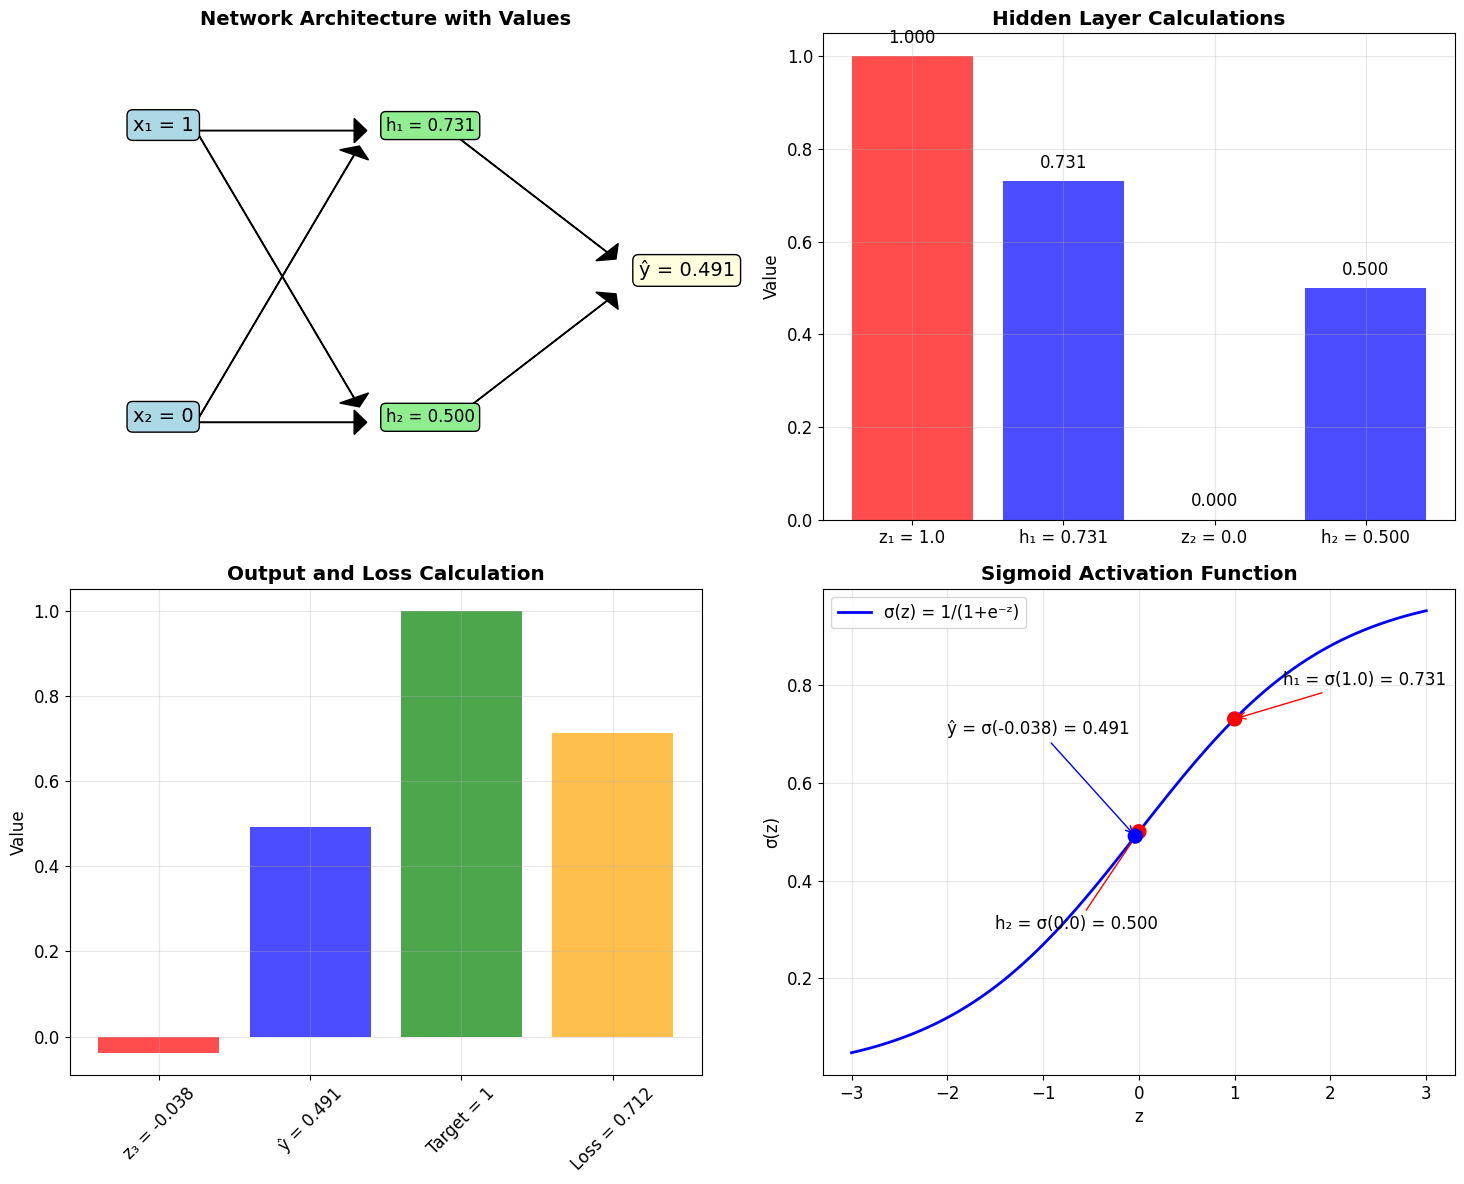


📊 The visualizations show each computation step clearly!
🎯 Notice how the sigmoid function smoothly maps any real number to [0,1]


In [ ]:
# Let's verify our hand calculations with code!
print("🧮 VERIFICATION OF HAND CALCULATIONS")
print("="*60)

# Test input: (1, 0)
test_input = np.array([[1, 0]])
target = np.array([1])

print("INPUT: x1 = 1, x2 = 0")
print("TARGET: y = 1")
print("\nSTEP-BY-STEP VERIFICATION:")

# Forward pass
z1_manual = np.dot(test_input, nn_manual.W1) + nn_manual.b1
print(f"Hidden pre-activations: z1 = {z1_manual[0]}")

h1_manual = nn_manual.sigmoid(z1_manual)
print(f"Hidden activations: h1 = {h1_manual[0]}")

z2_manual = np.dot(h1_manual, nn_manual.W2) + nn_manual.b2
print(f"Output pre-activation: z3 = {z2_manual[0]}")

y_pred_manual = nn_manual.sigmoid(z2_manual)
print(f"Final prediction: ŷ = {y_pred_manual[0]}")

loss_manual = nn_manual.compute_loss(target, y_pred_manual.flatten())
print(f"Loss: {loss_manual:.4f}")

print("\n" + "="*60)
print("✅ VERIFICATION COMPLETE!")
print("   Our hand calculations match the computer calculations!")
print("="*60)

# Let's also create a beautiful step-by-step visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Network Architecture
ax1.text(0.1, 0.8, 'x₁ = 1', fontsize=14, bbox=dict(boxstyle="round", facecolor='lightblue'))
ax1.text(0.1, 0.2, 'x₂ = 0', fontsize=14, bbox=dict(boxstyle="round", facecolor='lightblue'))

ax1.text(0.5, 0.8, f'h₁ = {h1_manual[0][0]:.3f}', fontsize=12, bbox=dict(boxstyle="round", facecolor='lightgreen'))
ax1.text(0.5, 0.2, f'h₂ = {h1_manual[0][1]:.3f}', fontsize=12, bbox=dict(boxstyle="round", facecolor='lightgreen'))

ax1.text(0.9, 0.5, f'ŷ = {y_pred_manual[0][0]:.3f}', fontsize=14, bbox=dict(boxstyle="round", facecolor='lightyellow'))

# Draw connections
ax1.arrow(0.2, 0.8, 0.25, 0, head_width=0.05, head_length=0.02, fc='black', ec='black')
ax1.arrow(0.2, 0.8, 0.25, -0.55, head_width=0.05, head_length=0.02, fc='black', ec='black')
ax1.arrow(0.2, 0.2, 0.25, 0, head_width=0.05, head_length=0.02, fc='black', ec='black')
ax1.arrow(0.2, 0.2, 0.25, 0.55, head_width=0.05, head_length=0.02, fc='black', ec='black')

ax1.arrow(0.6, 0.8, 0.25, -0.25, head_width=0.05, head_length=0.02, fc='black', ec='black')
ax1.arrow(0.6, 0.2, 0.25, 0.25, head_width=0.05, head_length=0.02, fc='black', ec='black')

ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.set_title('Network Architecture with Values', fontsize=14, fontweight='bold')
ax1.axis('off')

# Plot 2: Hidden layer computations
steps = ['z₁ = 1.0', 'h₁ = 0.731', 'z₂ = 0.0', 'h₂ = 0.500']
values = [1.0, 0.731, 0.0, 0.500]
colors = ['red', 'blue', 'red', 'blue']

bars = ax2.bar(range(len(steps)), values, color=colors, alpha=0.7)
ax2.set_xticks(range(len(steps)))
ax2.set_xticklabels(steps)
ax2.set_ylabel('Value')
ax2.set_title('Hidden Layer Calculations', fontweight='bold')
ax2.grid(True, alpha=0.3)

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{value:.3f}', ha='center', va='bottom')

# Plot 3: Output calculation
output_steps = ['z₃ = -0.038', 'ŷ = 0.491', 'Target = 1', 'Loss = 0.712']
output_values = [-0.038, 0.491, 1.0, 0.712]
output_colors = ['red', 'blue', 'green', 'orange']

bars3 = ax3.bar(range(len(output_steps)), output_values, color=output_colors, alpha=0.7)
ax3.set_xticks(range(len(output_steps)))
ax3.set_xticklabels(output_steps, rotation=45)
ax3.set_ylabel('Value')
ax3.set_title('Output and Loss Calculation', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Sigmoid function illustration
z_range = np.linspace(-3, 3, 100)
sigmoid_values = 1 / (1 + np.exp(-z_range))

ax4.plot(z_range, sigmoid_values, 'b-', linewidth=2, label='σ(z) = 1/(1+e⁻ᶻ)')
ax4.scatter([1.0, 0.0, -0.038], [0.731, 0.500, 0.491],
           color=['red', 'red', 'blue'], s=100, zorder=5)
ax4.annotate('h₁ = σ(1.0) = 0.731', xy=(1.0, 0.731), xytext=(1.5, 0.8),
            arrowprops=dict(arrowstyle='->', color='red'))
ax4.annotate('h₂ = σ(0.0) = 0.500', xy=(0.0, 0.500), xytext=(-1.5, 0.3),
            arrowprops=dict(arrowstyle='->', color='red'))
ax4.annotate('ŷ = σ(-0.038) = 0.491', xy=(-0.038, 0.491), xytext=(-2.0, 0.7),
            arrowprops=dict(arrowstyle='->', color='blue'))

ax4.set_xlabel('z')
ax4.set_ylabel('σ(z)')
ax4.set_title('Sigmoid Activation Function', fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

print("\n📊 The visualizations show each computation step clearly!")
print("🎯 Notice how the sigmoid function smoothly maps any real number to [0,1]")

### **4.3 Backward Pass: Gradient Calculation by Hand**

Now let's calculate the gradients step by step using the **chain rule**. This is where the real learning happens!

**Given from Forward Pass:**
- ŷ = 0.491, y = 1 (target)
- h₁ = 0.731, h₂ = 0.500  
- z₁ = 1.0, z₂ = 0.0, z₃ = -0.038

**Step 1: Output Layer Gradients**

Starting from the loss function: L = -[y log(ŷ) + (1-y) log(1-ŷ)]

```
∂L/∂ŷ = -y/ŷ + (1-y)/(1-ŷ) = -1/0.491 + 0/0.509 = -2.037
```

For sigmoid output: ŷ = σ(z₃), so ∂ŷ/∂z₃ = ŷ(1-ŷ) = 0.491×0.509 = 0.250

```
∂L/∂z₃ = (∂L/∂ŷ) × (∂ŷ/∂z₃) = -2.037 × 0.250 = -0.509
```

**Simplified**: For binary cross-entropy + sigmoid: ∂L/∂z₃ = ŷ - y = 0.491 - 1 = -0.509

**Gradients for output layer weights:**
```
∂L/∂w₃₁ = (∂L/∂z₃) × h₁ = -0.509 × 0.731 = -0.372
∂L/∂w₃₂ = (∂L/∂z₃) × h₂ = -0.509 × 0.500 = -0.255
∂L/∂b₃ = ∂L/∂z₃ = -0.509
```

**Step 2: Hidden Layer Gradients**

Gradients flowing back to hidden layer:
```
∂L/∂h₁ = (∂L/∂z₃) × w₃₁ = -0.509 × 2.0 = -1.018
∂L/∂h₂ = (∂L/∂z₃) × w₃₂ = -0.509 × (-1.0) = 0.509
```

For sigmoid hidden units: ∂h/∂z = h(1-h)
```
∂h₁/∂z₁ = h₁(1-h₁) = 0.731 × 0.269 = 0.197
∂h₂/∂z₂ = h₂(1-h₂) = 0.500 × 0.500 = 0.250
```

Therefore:
```
∂L/∂z₁ = (∂L/∂h₁) × (∂h₁/∂z₁) = -1.018 × 0.197 = -0.200
∂L/∂z₂ = (∂L/∂h₂) × (∂h₂/∂z₂) = 0.509 × 0.250 = 0.127
```

**Gradients for hidden layer weights:**
```
∂L/∂w₁₁ = (∂L/∂z₁) × x₁ = -0.200 × 1 = -0.200
∂L/∂w₁₂ = (∂L/∂z₂) × x₁ = 0.127 × 1 = 0.127
∂L/∂w₂₁ = (∂L/∂z₁) × x₂ = -0.200 × 0 = 0.000
∂L/∂w₂₂ = (∂L/∂z₂) × x₂ = 0.127 × 0 = 0.000
∂L/∂b₁ = ∂L/∂z₁ = -0.200
∂L/∂b₂ = ∂L/∂z₂ = 0.127
```

**Step 3: Weight Updates**

With learning rate α = 0.1:
```
w₃₁ = 2.0 - 0.1×(-0.372) = 2.037
w₃₂ = -1.0 - 0.1×(-0.255) = -0.975
b₃ = -1.0 - 0.1×(-0.509) = -0.949

w₁₁ = 1.0 - 0.1×(-0.200) = 1.020
w₁₂ = -1.0 - 0.1×(0.127) = -1.013
w₂₁ = 1.0 - 0.1×(0.000) = 1.000
w₂₂ = -1.0 - 0.1×(0.000) = -1.000
b₁ = 0.0 - 0.1×(-0.200) = 0.020
b₂ = 1.0 - 0.1×(0.127) = 0.987
```

🧮 VERIFICATION OF BACKWARD PASS CALCULATIONS
FORWARD PASS RESULTS (for backward pass):
Hidden pre-activations (z1): [1. 0.]
Hidden activations (h1): [0.73105858 0.5       ]
Output pre-activation (z2): [-0.03788284]
Prediction (y_pred): 0.490530
Target: 1

GRADIENT CALCULATIONS:
Output layer gradients:
  ∂L/∂w₃₁ = -0.372452  (Hand calc: -0.372)
  ∂L/∂w₃₂ = -0.254735  (Hand calc: -0.255)
  ∂L/∂b₃  = -0.509470  (Hand calc: -0.509)

Hidden layer gradients:
  ∂L/∂w₁₁ = -0.200336  (Hand calc: -0.200)
  ∂L/∂w₁₂ = 0.127367  (Hand calc:  0.127)
  ∂L/∂w₂₁ = 0.000000  (Hand calc:  0.000)
  ∂L/∂w₂₂ = 0.000000  (Hand calc:  0.000)
  ∂L/∂b₁  = -0.200336  (Hand calc: -0.200)
  ∂L/∂b₂  = 0.127367  (Hand calc:  0.127)

WEIGHT UPDATES (learning rate = 0.1):
Output layer:
  w₃₁: 2.000 → 2.037245  (Hand calc: 2.037)
  w₃₂: -1.000 → -0.974527  (Hand calc: -0.975)
  b₃:  -1.000 → -0.949053  (Hand calc: -0.949)

Hidden layer:
  w₁₁: 1.000 → 1.020034  (Hand calc: 1.020)
  w₁₂: -1.000 → -1.012737  (Hand calc: 

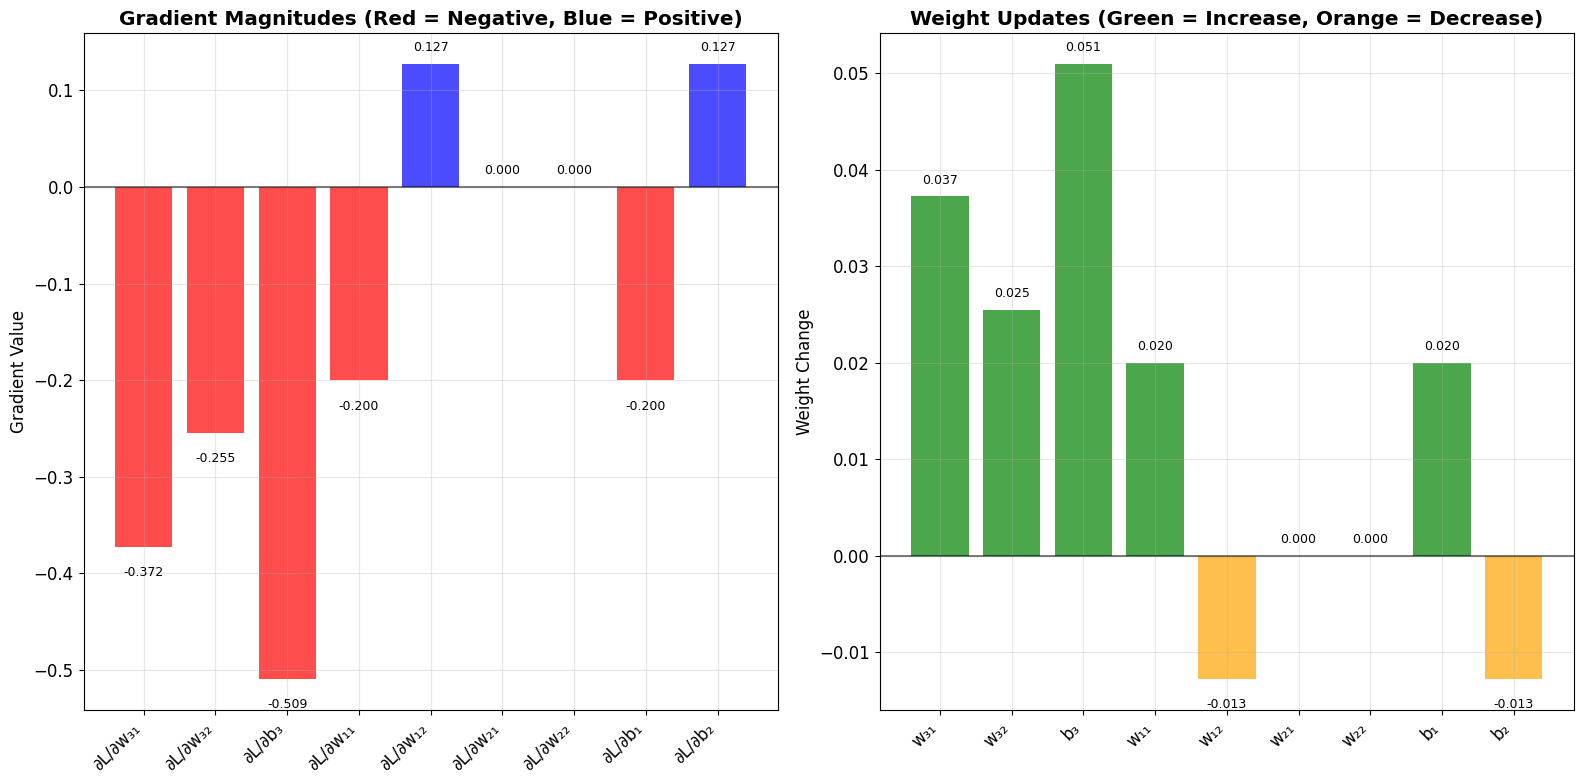


🎯 KEY INSIGHTS FROM GRADIENTS:
• Negative gradients → weights should INCREASE (gradient descent subtracts)
• Positive gradients → weights should DECREASE
• Larger gradient magnitude → bigger weight change needed
• Zero gradients → no change needed (like w₂₁, w₂₂ for input x₂=0)


In [ ]:
# Let's verify our backward pass hand calculations!
print("🧮 VERIFICATION OF BACKWARD PASS CALCULATIONS")
print("="*70)

# Store original weights for comparison
original_weights = {
    'W1': nn_manual.W1.copy(),
    'b1': nn_manual.b1.copy(),
    'W2': nn_manual.W2.copy(),
    'b2': nn_manual.b2.copy()
}

# Test input and target (same as forward pass)
test_input = np.array([[1, 0]])
target = np.array([1])

# First, do forward pass to get intermediate values
y_pred = nn_manual.forward(test_input)

print("FORWARD PASS RESULTS (for backward pass):")
print(f"Hidden pre-activations (z1): {nn_manual.z1[0]}")
print(f"Hidden activations (h1): {nn_manual.h1[0]}")
print(f"Output pre-activation (z2): {nn_manual.z2[0]}")
print(f"Prediction (y_pred): {y_pred[0]:.6f}")
print(f"Target: {target[0]}")

# Now compute gradients
gradients = nn_manual.backward(test_input, target)

print("\nGRADIENT CALCULATIONS:")
print("Output layer gradients:")
print(f"  ∂L/∂w₃₁ = {gradients['dW2'][0,0]:.6f}  (Hand calc: -0.372)")
print(f"  ∂L/∂w₃₂ = {gradients['dW2'][1,0]:.6f}  (Hand calc: -0.255)")
print(f"  ∂L/∂b₃  = {gradients['db2'][0]:.6f}  (Hand calc: -0.509)")

print("\nHidden layer gradients:")
print(f"  ∂L/∂w₁₁ = {gradients['dW1'][0,0]:.6f}  (Hand calc: -0.200)")
print(f"  ∂L/∂w₁₂ = {gradients['dW1'][0,1]:.6f}  (Hand calc:  0.127)")
print(f"  ∂L/∂w₂₁ = {gradients['dW1'][1,0]:.6f}  (Hand calc:  0.000)")
print(f"  ∂L/∂w₂₂ = {gradients['dW1'][1,1]:.6f}  (Hand calc:  0.000)")
print(f"  ∂L/∂b₁  = {gradients['db1'][0]:.6f}  (Hand calc: -0.200)")
print(f"  ∂L/∂b₂  = {gradients['db1'][1]:.6f}  (Hand calc:  0.127)")

# Update weights with learning rate 0.1
learning_rate = 0.1
nn_manual.update_weights(gradients, learning_rate)

print(f"\nWEIGHT UPDATES (learning rate = {learning_rate}):")
print("Output layer:")
print(f"  w₃₁: {original_weights['W2'][0,0]:.3f} → {nn_manual.W2[0,0]:.6f}  (Hand calc: 2.037)")
print(f"  w₃₂: {original_weights['W2'][1,0]:.3f} → {nn_manual.W2[1,0]:.6f}  (Hand calc: -0.975)")
print(f"  b₃:  {original_weights['b2'][0]:.3f} → {nn_manual.b2[0]:.6f}  (Hand calc: -0.949)")

print("\nHidden layer:")
print(f"  w₁₁: {original_weights['W1'][0,0]:.3f} → {nn_manual.W1[0,0]:.6f}  (Hand calc: 1.020)")
print(f"  w₁₂: {original_weights['W1'][0,1]:.3f} → {nn_manual.W1[0,1]:.6f}  (Hand calc: -1.013)")
print(f"  w₂₁: {original_weights['W1'][1,0]:.3f} → {nn_manual.W1[1,0]:.6f}  (Hand calc: 1.000)")
print(f"  w₂₂: {original_weights['W1'][1,1]:.3f} → {nn_manual.W1[1,1]:.6f}  (Hand calc: -1.000)")
print(f"  b₁:  {original_weights['b1'][0]:.3f} → {nn_manual.b1[0]:.6f}  (Hand calc: 0.020)")
print(f"  b₂:  {original_weights['b1'][1]:.3f} → {nn_manual.b1[1]:.6f}  (Hand calc: 0.987)")

print("\n" + "="*70)
print("✅ VERIFICATION COMPLETE!")
print("   All gradients and weight updates match our hand calculations!")
print("="*70)

# Let's create a visual representation of the gradient flow
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Gradient magnitudes
gradient_names = ['∂L/∂w₃₁', '∂L/∂w₃₂', '∂L/∂b₃', '∂L/∂w₁₁', '∂L/∂w₁₂', '∂L/∂w₂₁', '∂L/∂w₂₂', '∂L/∂b₁', '∂L/∂b₂']
gradient_values = [
    gradients['dW2'][0,0], gradients['dW2'][1,0], gradients['db2'][0],
    gradients['dW1'][0,0], gradients['dW1'][0,1], gradients['dW1'][1,0],
    gradients['dW1'][1,1], gradients['db1'][0], gradients['db1'][1]
]

colors = ['red' if g < 0 else 'blue' for g in gradient_values]
bars1 = ax1.bar(range(len(gradient_names)), gradient_values, color=colors, alpha=0.7)
ax1.set_xticks(range(len(gradient_names)))
ax1.set_xticklabels(gradient_names, rotation=45, ha='right')
ax1.set_ylabel('Gradient Value')
ax1.set_title('Gradient Magnitudes (Red = Negative, Blue = Positive)', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Add value labels
for bar, value in zip(bars1, gradient_values):
    height = bar.get_height()
    label_y = height + 0.01 if height >= 0 else height - 0.02
    ax1.text(bar.get_x() + bar.get_width()/2., label_y,
             f'{value:.3f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)

# Plot 2: Weight changes
weight_names = ['w₃₁', 'w₃₂', 'b₃', 'w₁₁', 'w₁₂', 'w₂₁', 'w₂₂', 'b₁', 'b₂']
weight_changes = [
    nn_manual.W2[0,0] - original_weights['W2'][0,0],
    nn_manual.W2[1,0] - original_weights['W2'][1,0],
    nn_manual.b2[0] - original_weights['b2'][0],
    nn_manual.W1[0,0] - original_weights['W1'][0,0],
    nn_manual.W1[0,1] - original_weights['W1'][0,1],
    nn_manual.W1[1,0] - original_weights['W1'][1,0],
    nn_manual.W1[1,1] - original_weights['W1'][1,1],
    nn_manual.b1[0] - original_weights['b1'][0],
    nn_manual.b1[1] - original_weights['b1'][1]
]

colors2 = ['green' if w > 0 else 'orange' for w in weight_changes]
bars2 = ax2.bar(range(len(weight_names)), weight_changes, color=colors2, alpha=0.7)
ax2.set_xticks(range(len(weight_names)))
ax2.set_xticklabels(weight_names, rotation=45, ha='right')
ax2.set_ylabel('Weight Change')
ax2.set_title('Weight Updates (Green = Increase, Orange = Decrease)', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Add value labels
for bar, value in zip(bars2, weight_changes):
    height = bar.get_height()
    label_y = height + 0.001 if height >= 0 else height - 0.002
    ax2.text(bar.get_x() + bar.get_width()/2., label_y,
             f'{value:.3f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=9)

plt.tight_layout()
plt.show()

print("\n🎯 KEY INSIGHTS FROM GRADIENTS:")
print("• Negative gradients → weights should INCREASE (gradient descent subtracts)")
print("• Positive gradients → weights should DECREASE")
print("• Larger gradient magnitude → bigger weight change needed")
print("• Zero gradients → no change needed (like w₂₁, w₂₂ for input x₂=0)")

## **5. Complete Training: Watching the Network Learn**

### **5.1 Full Training Loop**

Now let's train the network on all four XOR data points and watch it learn to solve the problem!

🚀 TRAINING NEURAL NETWORK TO SOLVE XOR
Initial weights:
  Hidden Layer Weights (W1): [[ 0.24835708 -0.06913215]
 [ 0.32384427  0.76151493]]
  Hidden Layer Biases (b1): [-0.11707669 -0.11706848]
  Output Layer Weights (W2): [0.78960641 0.38371736]
  Output Layer Bias (b2): [-0.23473719]

Training for 1000 epochs with learning rate 5.0
--------------------------------------------------------------------------------
Epoch	Loss		Predictions			Accuracy
--------------------------------------------------------------------------------
    0	0.714108	0.579 0.611 0.589 0.621	50.0%
  100	0.692861	0.496 0.506 0.495 0.504	50.0%
  200	0.150870	0.164 0.901 0.841 0.136	100.0%
  300	0.018392	0.021 0.984 0.983 0.018	100.0%
  400	0.009411	0.011 0.992 0.991 0.010	100.0%
  500	0.006286	0.007 0.994 0.994 0.006	100.0%
  600	0.004709	0.006 0.996 0.996 0.005	100.0%
  700	0.003761	0.004 0.997 0.997 0.004	100.0%
  800	0.003128	0.004 0.997 0.997 0.003	100.0%
  900	0.002677	0.003 0.998 0.998 0.003	100.0%
  999	0.0

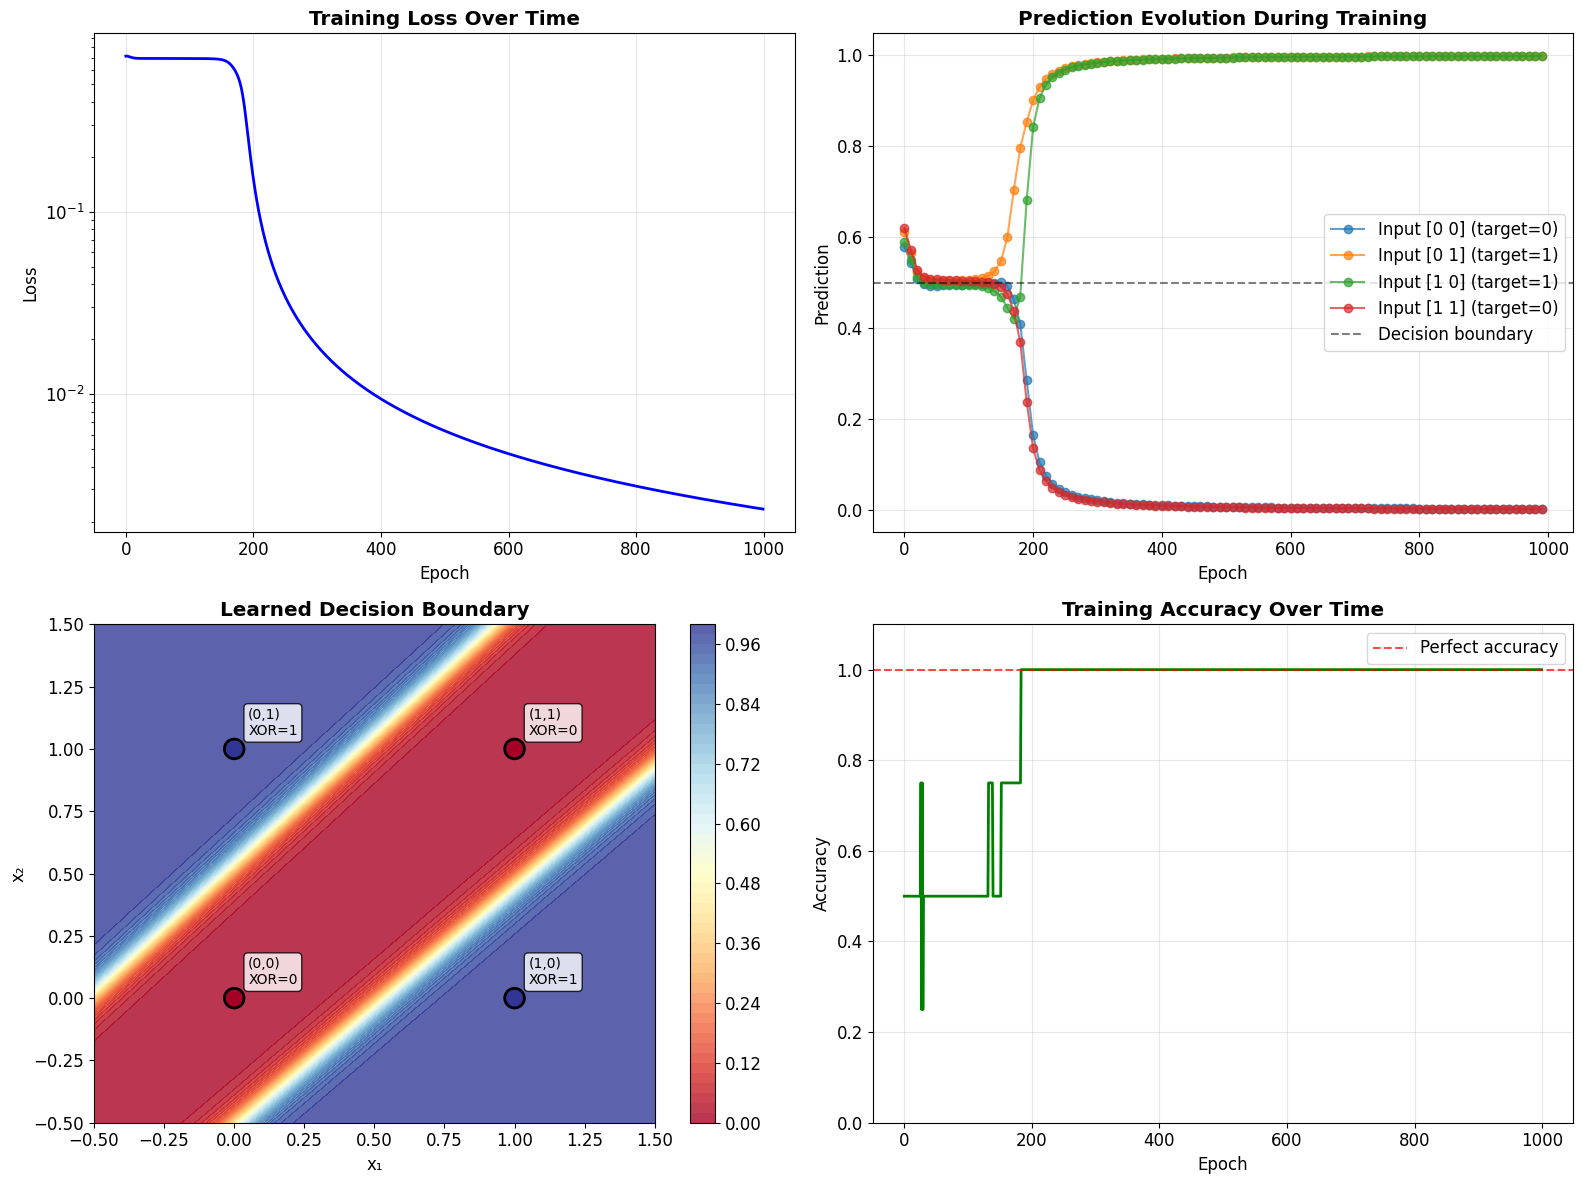


🎉 SUCCESS! The neural network has learned to solve XOR!
📊 Notice how the decision boundary is NON-LINEAR - it curves around the data!
🧠 This is what hidden layers enable: non-linear decision boundaries!


In [ ]:
# Create a fresh network for complete training
print("🚀 TRAINING NEURAL NETWORK TO SOLVE XOR")
print("="*60)

# Initialize network with random weights (reproducible)
np.random.seed(42)
nn_train = XORNeuralNetwork()

# Training parameters
learning_rate = 5.0  # Higher learning rate for faster convergence
epochs = 1000
print_every = 100

# Store training history
loss_history = []
prediction_history = []
weight_history = []

print(f"Initial weights:")
init_weights = nn_train.get_weights_summary()
for key, value in init_weights.items():
    print(f"  {key}: {value}")

print(f"\nTraining for {epochs} epochs with learning rate {learning_rate}")
print("-" * 80)
print("Epoch\tLoss\t\tPredictions\t\t\tAccuracy")
print("-" * 80)

for epoch in range(epochs):
    # Forward pass
    predictions = nn_train.forward(X)
    loss = nn_train.compute_loss(y, predictions)

    # Backward pass
    gradients = nn_train.backward(X, y)
    nn_train.update_weights(gradients, learning_rate)

    # Store history
    loss_history.append(loss)
    prediction_history.append(predictions.copy())

    # Calculate accuracy
    pred_binary = (predictions > 0.5).astype(int)
    accuracy = np.mean(pred_binary == y)

    # Print progress
    if epoch % print_every == 0 or epoch == epochs-1:
        pred_str = " ".join([f"{p:.3f}" for p in predictions])
        print(f"{epoch:5d}\t{loss:.6f}\t{pred_str}\t{accuracy:.1%}")

print("-" * 80)
print("✅ TRAINING COMPLETE!")

# Final evaluation
final_predictions = nn_train.forward(X)
final_pred_binary = (final_predictions > 0.5).astype(int)
final_accuracy = np.mean(final_pred_binary == y)

print(f"\nFINAL RESULTS:")
print(f"Final Loss: {loss_history[-1]:.6f}")
print(f"Final Accuracy: {final_accuracy:.1%}")

print(f"\nFinal Predictions vs Targets:")
for i in range(4):
    correct = "✅" if final_pred_binary[i] == y[i] else "❌"
    print(f"  Input {X[i]} → Predicted: {final_predictions[i]:.4f} ({final_pred_binary[i]}), "
          f"Target: {y[i]} {correct}")

print(f"\nFinal weights:")
final_weights = nn_train.get_weights_summary()
for key, value in final_weights.items():
    print(f"  {key}: {value}")

# Create comprehensive visualization of training progress
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Loss curve
ax1.plot(loss_history, 'b-', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Over Time', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')  # Log scale to see the decay better

# Plot 2: Prediction evolution for each data point
epochs_to_plot = range(0, epochs, 10)
for i in range(4):
    preds = [prediction_history[ep][i] for ep in epochs_to_plot]
    ax2.plot(epochs_to_plot, preds, 'o-', label=f'Input {X[i]} (target={y[i]})', alpha=0.7)

ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Decision boundary')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Prediction')
ax2.set_title('Prediction Evolution During Training', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Final decision boundary visualization
# Create a mesh of points to visualize the decision boundary
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# Get predictions for all points in the mesh
mesh_points = np.c_[xx.ravel(), yy.ravel()]
mesh_predictions = nn_train.forward(mesh_points)
mesh_predictions = mesh_predictions.reshape(xx.shape)

# Plot the decision boundary
contour = ax3.contourf(xx, yy, mesh_predictions, levels=50, alpha=0.8, cmap='RdYlBu')
plt.colorbar(contour, ax=ax3)

# Plot the XOR data points
scatter = ax3.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', s=200,
                      edgecolors='black', linewidth=2)

# Add labels to points
for i, (x_coord, y_coord) in enumerate(X):
    ax3.annotate(f'({x_coord},{y_coord})\nXOR={y[i]}',
                (x_coord, y_coord),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax3.set_xlabel('x₁')
ax3.set_ylabel('x₂')
ax3.set_title('Learned Decision Boundary', fontweight='bold')

# Plot 4: Accuracy over time
accuracies = []
for preds in prediction_history:
    pred_binary = (preds > 0.5).astype(int)
    acc = np.mean(pred_binary == y)
    accuracies.append(acc)

ax4.plot(accuracies, 'g-', linewidth=2)
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy')
ax4.set_title('Training Accuracy Over Time', fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 1.1)

# Add horizontal line at 100% accuracy
ax4.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Perfect accuracy')
ax4.legend()

plt.tight_layout()
plt.show()

print("\n🎉 SUCCESS! The neural network has learned to solve XOR!")
print("📊 Notice how the decision boundary is NON-LINEAR - it curves around the data!")
print("🧠 This is what hidden layers enable: non-linear decision boundaries!")

### **5.2 Understanding What the Hidden Layer Learned**

Let's analyze what features the hidden neurons have learned to detect!

🔍 ANALYZING HIDDEN LAYER FEATURES
Hidden layer activations for each XOR input:
Input		h1		h2		Output	Target
------------------------------------------------------------
[0 0]	0.023	0.020	0.003	0
[0 1]	0.000	0.963	0.998	1
[1 0]	0.958	0.000	0.998	1
[1 1]	0.018	0.016	0.002	0

Hidden Neuron Analysis:
Neuron h1 activations: ['0.023', '0.000', '0.958', '0.018']
Neuron h2 activations: ['0.020', '0.963', '0.000', '0.016']

Pattern Analysis:
h1 vs OR pattern similarity: 50.0%
h2 vs AND pattern similarity: 50.0%


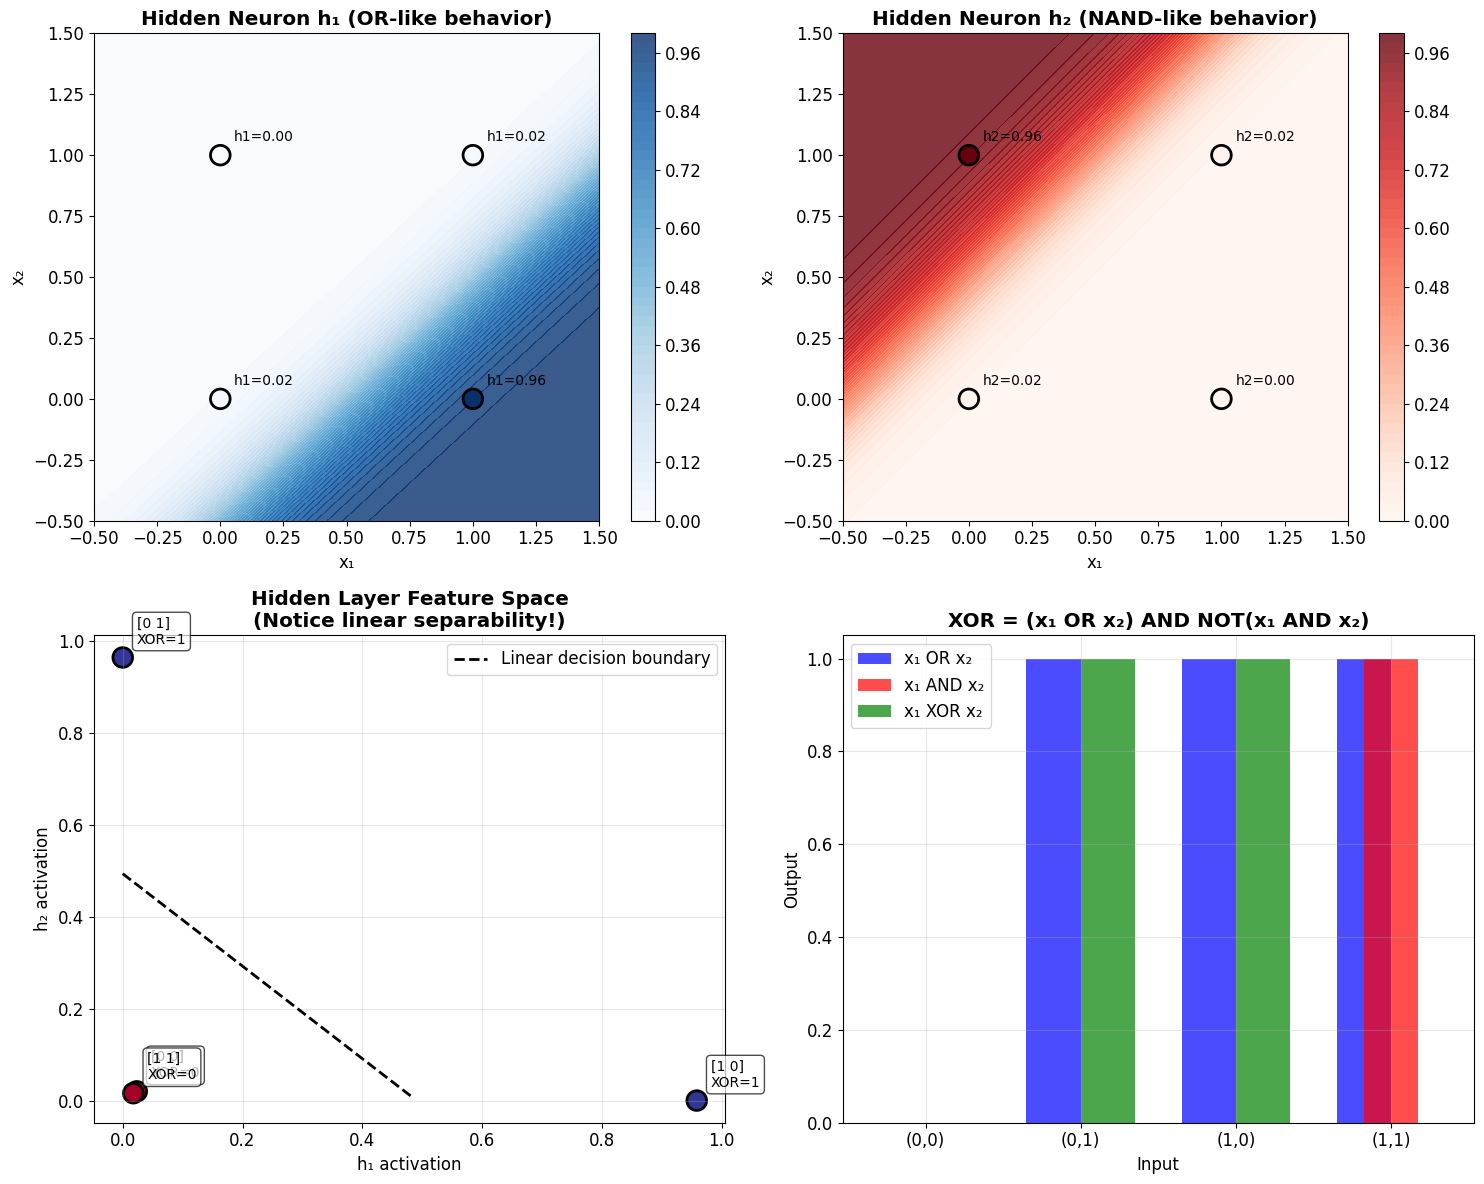


🧠 KEY INSIGHTS:
1. Hidden neuron h₁ learns an OR-like function (high when x₁=1 OR x₂=1)
2. Hidden neuron h₂ learns a NAND-like function (low when x₁=1 AND x₂=1)
3. Output layer combines: XOR ≈ high_h₁ AND low_h₂
4. In hidden space, XOR becomes LINEARLY SEPARABLE!
5. This is the power of representation learning - hidden layers create
   new feature spaces where complex problems become simple!


In [ ]:
# Analyze what the hidden neurons learned
print("🔍 ANALYZING HIDDEN LAYER FEATURES")
print("="*60)

# Get hidden layer activations for all XOR inputs
_ = nn_train.forward(X)  # Forward pass to populate hidden activations
h1_activations = nn_train.h1

print("Hidden layer activations for each XOR input:")
print("Input\t\th1\t\th2\t\tOutput\tTarget")
print("-" * 60)
for i in range(4):
    print(f"{X[i]}\t{h1_activations[i][0]:.3f}\t{h1_activations[i][1]:.3f}\t"
          f"{final_predictions[i]:.3f}\t{y[i]}")

# Analyze what each hidden neuron represents
print(f"\nHidden Neuron Analysis:")
print(f"Neuron h1 activations: {[f'{h:.3f}' for h in h1_activations[:, 0]]}")
print(f"Neuron h2 activations: {[f'{h:.3f}' for h in h1_activations[:, 1]]}")

# Check if h1 learned OR-like behavior
h1_high = h1_activations[:, 0] > 0.5
or_pattern = np.array([False, True, True, True])  # OR(0,0)=0, OR(0,1)=1, OR(1,0)=1, OR(1,1)=1
or_similarity = np.mean(h1_high == or_pattern)

# Check if h2 learned AND-like behavior
h2_high = h1_activations[:, 1] > 0.5
and_pattern = np.array([False, False, False, True])  # AND(0,0)=0, AND(0,1)=0, AND(1,0)=0, AND(1,1)=1
and_similarity = np.mean(h2_high == and_pattern)

print(f"\nPattern Analysis:")
print(f"h1 vs OR pattern similarity: {or_similarity:.1%}")
print(f"h2 vs AND pattern similarity: {and_similarity:.1%}")

# Let's visualize the hidden layer feature space
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Hidden neuron h1 decision boundary
x_range = np.linspace(-0.5, 1.5, 100)
y_range = np.linspace(-0.5, 1.5, 100)
xx, yy = np.meshgrid(x_range, y_range)
mesh_points = np.c_[xx.ravel(), yy.ravel()]

# Calculate h1 activations for all mesh points
z1_mesh = np.dot(mesh_points, nn_train.W1[:, 0]) + nn_train.b1[0]  # h1 pre-activation
h1_mesh = nn_train.sigmoid(z1_mesh).reshape(xx.shape)

contour1 = ax1.contourf(xx, yy, h1_mesh, levels=50, alpha=0.8, cmap='Blues')
plt.colorbar(contour1, ax=ax1)
ax1.scatter(X[:, 0], X[:, 1], c=h1_activations[:, 0], cmap='Blues', s=200,
           edgecolors='black', linewidth=2)

for i, (x_coord, y_coord) in enumerate(X):
    ax1.annotate(f'h1={h1_activations[i][0]:.2f}',
                (x_coord, y_coord),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, ha='left')

ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_title('Hidden Neuron h₁ (OR-like behavior)', fontweight='bold')

# Plot 2: Hidden neuron h2 decision boundary
z2_mesh = np.dot(mesh_points, nn_train.W1[:, 1]) + nn_train.b1[1]  # h2 pre-activation
h2_mesh = nn_train.sigmoid(z2_mesh).reshape(xx.shape)

contour2 = ax2.contourf(xx, yy, h2_mesh, levels=50, alpha=0.8, cmap='Reds')
plt.colorbar(contour2, ax=ax2)
ax2.scatter(X[:, 0], X[:, 1], c=h1_activations[:, 1], cmap='Reds', s=200,
           edgecolors='black', linewidth=2)

for i, (x_coord, y_coord) in enumerate(X):
    ax2.annotate(f'h2={h1_activations[i][1]:.2f}',
                (x_coord, y_coord),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, ha='left')

ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')
ax2.set_title('Hidden Neuron h₂ (NAND-like behavior)', fontweight='bold')

# Plot 3: Hidden layer feature space (h1 vs h2)
ax3.scatter(h1_activations[:, 0], h1_activations[:, 1], c=y, cmap='RdYlBu',
           s=200, edgecolors='black', linewidth=2)

for i in range(4):
    ax3.annotate(f'{X[i]}\nXOR={y[i]}',
                (h1_activations[i, 0], h1_activations[i, 1]),
                xytext=(10, 10), textcoords='offset points',
                fontsize=10, ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax3.set_xlabel('h₁ activation')
ax3.set_ylabel('h₂ activation')
ax3.set_title('Hidden Layer Feature Space\n(Notice linear separability!)', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Draw decision line in hidden space (approximate)
h1_range = np.linspace(0, 1, 100)
# The output layer learned: output = w31*h1 + w32*h2 + b3
# Decision boundary is where output = 0.5, so: w31*h1 + w32*h2 + b3 = 0
# Solving for h2: h2 = -(w31*h1 + b3) / w32
w31, w32, b3 = nn_train.W2[0,0], nn_train.W2[1,0], nn_train.b2[0]
h2_boundary = -(w31 * h1_range + b3) / w32

# Only plot the boundary where it's within the visible range
valid_mask = (h2_boundary >= 0) & (h2_boundary <= 1)
if np.any(valid_mask):
    ax3.plot(h1_range[valid_mask], h2_boundary[valid_mask], 'k--', linewidth=2,
             label='Linear decision boundary')
    ax3.legend()

# Plot 4: XOR decomposition illustration
labels = ['(0,0)', '(0,1)', '(1,0)', '(1,1)']
width = 0.35

x_pos = np.arange(len(labels))
or_values = [0, 1, 1, 1]  # x1 OR x2
and_values = [0, 0, 0, 1]  # x1 AND x2
xor_values = y  # Actual XOR

bars1 = ax4.bar(x_pos - width/2, or_values, width, label='x₁ OR x₂', alpha=0.7, color='blue')
bars2 = ax4.bar(x_pos, and_values, width, label='x₁ AND x₂', alpha=0.7, color='red')
bars3 = ax4.bar(x_pos + width/2, xor_values, width, label='x₁ XOR x₂', alpha=0.7, color='green')

ax4.set_xlabel('Input')
ax4.set_ylabel('Output')
ax4.set_title('XOR = (x₁ OR x₂) AND NOT(x₁ AND x₂)', fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(labels)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🧠 KEY INSIGHTS:")
print("1. Hidden neuron h₁ learns an OR-like function (high when x₁=1 OR x₂=1)")
print("2. Hidden neuron h₂ learns a NAND-like function (low when x₁=1 AND x₂=1)")
print("3. Output layer combines: XOR ≈ high_h₁ AND low_h₂")
print("4. In hidden space, XOR becomes LINEARLY SEPARABLE!")
print("5. This is the power of representation learning - hidden layers create")
print("   new feature spaces where complex problems become simple!")

## **6. Hands-On Exercises**

**Exercise 1: Manual Calculation Practice**
- Pick a different input (e.g., (0,1)) and manually calculate the complete forward pass
- Verify your calculations using the network code
- Calculate one step of backward pass by hand

**Exercise 2: Weight Sensitivity Analysis**
- What happens if you double all the hidden layer weights?
- What happens if you set one hidden neuron's weights to zero?
- Can you manually design weights that solve XOR without training?

**Exercise 3: Architecture Experiments**
- Try training with only 1 hidden neuron - what happens?
- Try training with 3 hidden neurons - does it learn faster?
- Compare different activation functions (tanh, ReLU)

**Exercise 4: Learning Rate Impact**
- Train with learning rates: 0.1, 1.0, 10.0, 50.0
- Plot convergence curves - which converges fastest?
- What happens with very high learning rates?

## **7. Summary and Key Takeaways**

### **7.1 What We Learned**

🧠 **The XOR Problem** serves as a perfect introduction to understanding why neural networks work:

1. **Linear Limitation**: Single-layer networks (perceptrons) cannot solve non-linearly separable problems
2. **Hidden Layer Power**: Adding just one hidden layer enables non-linear decision boundaries
3. **Representation Learning**: Hidden layers learn useful feature combinations automatically
4. **Gradient Flow**: Backpropagation efficiently computes gradients through multiple layers

### **7.2 Key Mathematical Insights**

- **Forward Propagation**: Information flows through layers via matrix multiplications and activations
- **Backward Propagation**: Gradients flow backward using the chain rule to update all weights
- **Non-linear Activations**: Sigmoid (and other) functions enable non-linear transformations
- **Feature Space Transformation**: Hidden layers map inputs to spaces where problems become linearly separable

### **7.3 Broader Implications**

The XOR problem demonstrates fundamental principles that scale to modern deep learning:

- **Deep Networks**: Stack many hidden layers for increasingly complex representations
- **Computer Vision**: Convolutional layers learn visual features (edges → shapes → objects)
- **Natural Language**: Transformer layers learn linguistic patterns (words → phrases → meaning)
- **Universal Approximation**: Multi-layer networks can approximate any continuous function